# Classical models and arithmetic implementation

In [1]:
# allows us to have visibility on our package without installing it in editing mode
import sys
if ".." not in sys.path: sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
from scipy.special import ive
from numpy.polynomial.chebyshev import chebval
from monaqa2.mcmc.model import RandomIsingModel

We map our comparison made in terms of the number of queries to actual runtimes. 

The classical models we consider for the runtime of classical MCMC walks are three:

* A fully sequential processor; such a processor works at the highest frequencies and has optimized logic for the arithmetic, however we have no flexibility to calculate the energy difference in parallel and thus we have to iterate sequentially on the list of changed terms. This is a system based on a single core, high performance CPU with large cache. 
* A fully parallel processor; such a processor allow us to calculate in parallel the energy difference as we design the combinatorial circuit with full flexibility. The asymptotic scaling is logarithm instead of linear in the number of terms, albeit this flexibility costs us in terms of slower frequencies and thus worse prefactors. This is a system based on a FPGA.
* A throughput-oriented processor; such a processor is not ideal for accelerating a single MCMC trajectory, because the Markov-chain time direction remains sequential. However, it can run many independent MCMC chains in parallel. This corresponds to a GPU-based system. The time for one step of one chain is expected to be comparable to, or potentially worse than, the CPU implementation because of branching, synchronization, and less efficient scalar control flow. The advantage of the GPU is instead throughput: when many independent chains or instances must be simulated, the relevant metric is not the latency of one chain, but the total wall-clock time required to process all chains. In that regime, the massive parallelism and memory bandwidth of the GPU can provide an advantage.

We select top-tier yet realistic examples of these processors. The CPU-based system features a Intel Xeon Platinum 8480, as based on a node of the Cineca Leonardo DCGP supercomputer. The FPGA is a AMD Virtex UltraScale+ XCVU19P (-2FSVA3824E). The GPU-based system is [todo]. 

We determine the time per classical operation as:
1. For the CPU-based system, we write a C++ program compiled and optimized with the most aggressive settings for the targetted system; we then generate 10 instances per each of the spin size $n$ tested we run 10 milion steps per system. The time per operation is determined by dividing the total time per 10 milion, then iterpolating the polynomial:
    * $P_\text{local}^\text{CPU}(x) = a + b n$ for the classical walk with the local move,
    * $P_\text{unif}^\text{CPU}(x) = a + b n + c n^2$ for the classical walk with the uniform move,
    * for $a, b, c \ge 0$.
   
    This difference is due to the local spin flip requiring to check only $n$ terms constributing for the energy difference while the uniform move potentially changes any of the $O(n^2)$ terms in the SK model. The constants $a, a'$ are considered time contribution to setup the computation and therefore is discarded.

2. For the FPGA-based system, we write a C program then via high-level syntesis in the tool AMD Vitis this is mapped to a combinatorial circuit then directly onto the target FPGA. Note that, even with the high-end target FPGA chosen, we are able to perform the synthesis of these circuits up to moderate $n$ spins (then we run out of space); our timing interpolates the value we can actually syntetize and for larger $n$ we project this timing disregarding any area limitation. This is in analogy with the model of quantum computation, in which we disregard the fact that the number of qubits, however it grows, must fit a chip and exceeding that would require multiple chips and communication overhead. For both local and uniform functions we fit:

   * $P_\text{local}^\text{FPGA}(n) = P_\text{unif}^\text{FPGA}(n) = a + b \log(n)$
  

## Precision of the arithmetic

Ideally, we desire to sample from a distribution $q_t = P^t q_0$ such that $\|q_t - \pi\|_\text{TV} \le \varepsilon$. In practice, the transition matrix $P$ is determined up to a certain precision of the arithmetic to the actual transition matrix $\tilde{P}$. The error introduced by this arithmetic can be quantificated as 

$$\| (\tilde{P})^t q_0 - \pi \| \; \le \; \underbrace{\| (\tilde{P})^t q_0 - \tilde\pi \|}_{\text{mixing error}} + \underbrace{\| \tilde\pi - \pi \|}_{\text{arithmetic error}}$$

This equation is rooted in the TV distance satisfying the triangle inequality and is paramount to avoid the need of the arithmetic error to depend on the number of steps $t$ (as $t$ may be very large). 

To obtain a target TV error $\varepsilon$ we budget the arithmetic error to be a negligible fraction of the allowed error, we set 
$$\varepsilon_\text{arith} = \frac{\varepsilon}{50}$$

We can budget this error as 
* $\varepsilon_\text{discr} = \varepsilon_\text{arith}/2$ for the discretization of the Ising coefficients,
* $\varepsilon_\text{operation} = \varepsilon_\text{arith}/2$ for the allowed error on the non-linear arithmetic. 

### Discretization error 

Let $\alpha = 2 (\sum_{ij} |J_{ij}| + \sum_i |h_i|)$ be a loose but easy to calculate upper bound on the energy difference $\Delta E$ of a fixed instance. In our SK models, the expected $\alpha$ grows as $\mathbb{E}[\alpha(n)] = 2 n^{3/2} / \sqrt{\pi}$. The terms will be all divided by this normalization term so that $\Delta E \in [-1, 1)$ is bounded. 

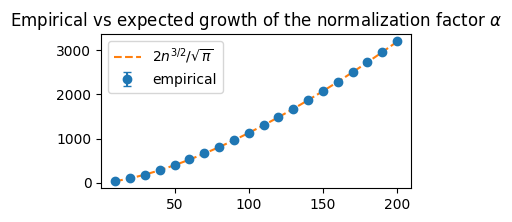

In [29]:
def alpha(m):
    return 2*(np.abs(m.h_rescaled).sum() + np.abs(np.triu(m.J_rescaled, 1)).sum())

ns = np.arange(10, 200+1, 10)
A = np.array([[alpha(RandomIsingModel(n, seed=n*i+33)) for i in range(30)] for n in ns])

plt.figure(figsize=(4, 2))
plt.errorbar(ns, A.mean(1), yerr=A.std(1), fmt="o", capsize=3, label="empirical")
plt.plot(ns, 2/np.sqrt(np.pi)*ns**1.5, "--", label=r"$2n^{3/2}/\sqrt{\pi}$")
plt.title("Empirical vs expected growth of the normalization factor $\\alpha$")
plt.legend()
plt.show()

Let $N = n (n+1)/2$ the number of Ising terms to be processed in the worst case scenario for out SK model and any trial move. Then, a precision of $f$ fractional bits creates an error in calculating the energy of the model equal to 

$$|\hat{E}(x) - E(x)| \le N \alpha 2^{-f} \le \varepsilon_\text{discr}$$

so that we can choose 

$$f \ge 
\left\lceil \log_2\left(\frac{N \alpha}{\varepsilon_\text{discr}}\right) \right\rceil \approx 
\left\lceil \frac{7}{2} \log\left(\pi^{-1/7} n\right) - \log_2(\varepsilon_\text{discr}) \right\rceil 
\approx 
\left\lceil \frac{7}{2} \log\left(n\right) - \log_2(\varepsilon_\text{discr}) \right\rceil 
$$

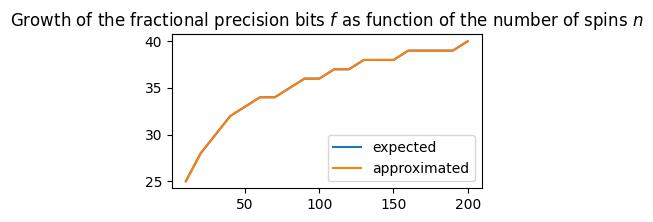

In [39]:
def fractional_bits(n, eps):
    N = n * (n+1) / 2
    alpha = (2/np.sqrt(np.pi)) * n * np.sqrt(n)
    return np.ceil(np.log2(N * alpha / eps))

def approx_fractional_bits(n, eps):
    return np.ceil(3.5 * np.log2((np.pi**(-1/7)) * n) - np.log2(eps))

eps_discr = 1e-4
plt.figure(figsize=(4, 2))
plt.plot(ns, [fractional_bits(n, eps_discr) for n in ns], label="expected")
plt.plot(ns, [approx_fractional_bits(n, eps_discr) for n in ns], label="approximated")
plt.title("Growth of the fractional precision bits $f$ as function of the number of spins $n$")
plt.legend()
plt.show()

### Operation error 

The operation error can be intended as the error made when implementing the function $g(x)=\exp(-\beta\alpha x)$, where $x=\Delta E/\alpha\in[0,1]$ is the normalized positive energy difference and $\alpha$ is chosen so that $|\Delta E|/\alpha\le 1$. Let $\lambda=\beta\alpha$. If we approximate $g$ by a degree-$d$ Chebyshev polynomial $p_d$, the truncation error satisfies the standard Bessel-tail bound
$$
\|g-p_d\|_\infty
\le
2e^{-\lambda/2}\sum_{k>d} I_k(\lambda/2)
\le \varepsilon_{\rm op},
$$
where $I_k$ is the modified Bessel function of the first kind.

A useful closed-form estimate follows from the Bernstein-type tail bound
$2e^{-a}\sum_{k>d} I_k(a)\lesssim 2\exp[-d^2/(2a+2d/3)]$, with $a=\lambda/2$. Setting $L=\log(2/\varepsilon_{\rm op})$ and requiring $d^2/(2a+2d/3)\gtrsim L$ gives the practical choice
$$
d
\approx
\left\lceil
\sqrt{\beta\alpha\log\!\left(\frac{2}{\varepsilon_{\rm op}}\right)}
+
\frac{2}{3}\log\!\left(\frac{2}{\varepsilon_{\rm op}}\right)
\right\rceil .
$$
Thus the global polynomial degree scales roughly as $\sqrt{\beta\alpha}$, up to logarithmic factors in $1/\varepsilon_{\rm op}$.

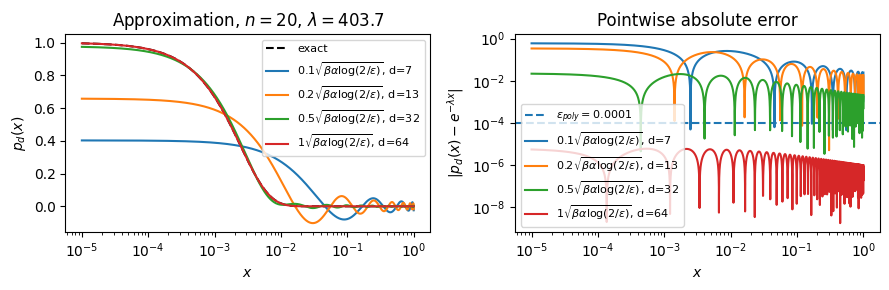

In [1]:
import numpy as np, matplotlib.pyplot as plt
from scipy.special import ive
from numpy.polynomial.chebyshev import chebval

beta, eps_poly, n0 = 4, 1e-4, 20
fracs = [1/10, 1/5, 1/2, 1]

alpha = lambda n: 2 / np.sqrt(np.pi) * n**1.5

def approx(lam, d, x):
    k, a = np.arange(d + 1), lam / 2
    c = 2 * (-1)**k * ive(k, a)
    c[0] /= 2
    return chebval(2*x - 1, c)

lam = beta * alpha(n0)
base_d = np.sqrt(lam * np.log(2 / eps_poly))
x = np.geomspace(1e-5, 1, 8000)
g = np.exp(-lam * x)

fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].plot(x, g, "k--", label="exact")
ax[1].axhline(eps_poly, ls="--", label=fr"$\epsilon_{{poly}}={eps_poly}$")

for f in fracs:
    d = int(np.ceil(f * base_d))
    p = approx(lam, d, x)
    lab = fr"${f:g}\sqrt{{\beta\alpha\log(2/\epsilon)}}$, d={d}"
    ax[0].plot(x, p, label=lab)
    ax[1].plot(x, abs(p - g), label=lab)

for a in ax:
    a.set_xscale("log")
    a.set_xlabel(r"$x$")
    a.legend(fontsize=8)

ax[0].set(title=fr"Approximation, $n={n0}$, $\lambda={lam:.1f}$", ylabel=r"$p_d(x)$")
ax[1].set(title="Pointwise absolute error", ylabel=r"$|p_d(x)-e^{-\lambda x}|$", yscale="log")

plt.tight_layout()
plt.show()

In [30]:
n0 = 20
d = 30
lam = beta * alpha(n0)

X = np.geomspace(1e-8, 1, 1000)
g = np.exp(-lam * X)
approx_value = [approx(lam, d, x) for x in X]

In [31]:
np.max(np.abs(g - approx_value))

np.float64(0.03183266842138743)

The scaling in $\sqrt{\beta \alpha}$ is quite expensive. The source of this cost is the boundary layer near $x=0$, where the function $e^{-\beta\alpha x}$ drops from $1$ to a negligible value over a scale $x=O((\beta\alpha)^{-1})$.

From a practical perspective, there is a negligible difference between the desired function and the easier-to-approximate piecewise function
$$
\widetilde g(x)=
\begin{cases}
e^{-\beta\alpha x}, & 0\le \beta\alpha x\le \tau,\\
0, & \beta\alpha x>\tau,
\end{cases}
$$
where $\tau=\log(1/\varepsilon_{\rm tail})$. 

Indeed, for $\beta\alpha x\ge \tau$, the discarded tail satisfies $e^{-\beta\alpha x}\le e^{-\tau}=\varepsilon_{\rm tail}$.

Thus, instead of approximating $e^{-\beta\alpha x}$ on the full interval $x\in[0,1]$, we set $u=\beta\alpha x$ and approximate $e^{-u}$ only on $u\in[0,\tau]$. Around the problematic region $x=0$, this is exactly the same function, but expressed in the rescaled variable $u$. Away from it, where $u\ge \tau$, the acceptance probability is already below the chosen tolerance and can be set to zero.

This time it is sufficient to choose a degree
$$
d
\approx
\left\lceil
\sqrt{\log\!\left(\frac{1}{\varepsilon_{\rm tail}}\right)\log\!\left(\frac{2}{\varepsilon_{\rm poly}}\right)}
+
\frac{2}{3}\log\!\left(\frac{2}{\varepsilon_{\rm poly}}\right)
\right\rceil
\approx
\left\lceil
2 \log(4 \varepsilon_\text{op}^{-1})
\right\rceil,
$$
taking $\varepsilon_{\rm tail}=\varepsilon_{\rm poly}=\varepsilon_{\rm op}/2$.

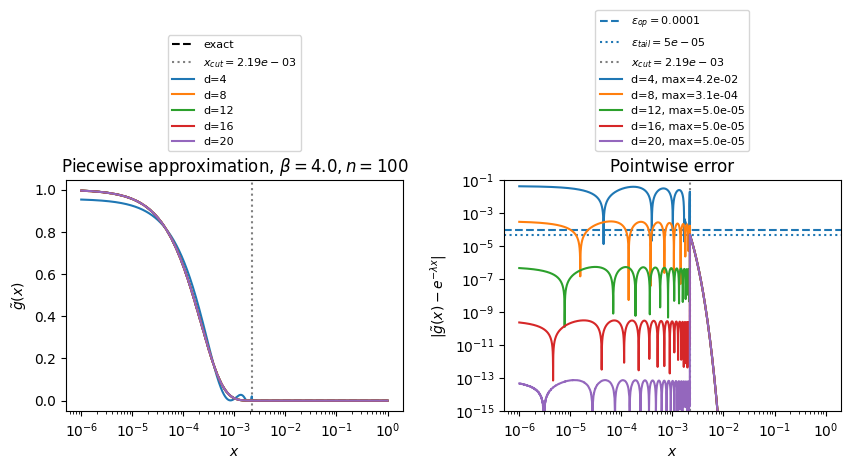

In [32]:
import numpy as np, matplotlib.pyplot as plt
from scipy.special import ive
from numpy.polynomial.chebyshev import chebval

beta = 4
eps_op = 1e-4
n0 = 100

eps_tail = eps_poly = eps_op / 2
degrees = [4, 8, 12, 16, 20]
alpha = lambda n: 2 / np.sqrt(np.pi) * n**1.5

def coeffs(tau, d):
    k, a = np.arange(d + 1), tau / 2
    c = 2 * (-1)**k * ive(k, a)
    c[0] /= 2
    return c

def piecewise_exp(x, lam, tau, d):
    u, p = lam * np.maximum(x, 0), np.zeros_like(x)
    m = (x > 0) & (u < tau)
    p[x <= 0] = 1
    p[m] = chebval(2*u[m]/tau - 1, coeffs(tau, d))
    return np.clip(p, 0, 1)

lam, tau = beta * alpha(n0), np.log(1 / eps_tail)
x_cut = tau / lam
x = np.geomspace(1e-6, 1, 8000)
exact = np.exp(-lam * x)
approx = piecewise_exp(x, lam, tau, d=12)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
fig.subplots_adjust(wspace=0.3)
ax[0].plot(x, exact, "k--", label="exact")
ax[1].axhline(eps_op, ls="--", label=fr"$\varepsilon_{{op}}={eps_op}$")
ax[1].axhline(eps_tail, ls=":", label=fr"$\varepsilon_{{tail}}={eps_tail}$")

for a in ax:
    a.axvline(x_cut, ls=":", color="gray", label=fr"$x_{{cut}}={x_cut:.2e}$")

for d in degrees:
    approx = piecewise_exp(x, lam, tau, d)
    err = abs(approx - exact)
    ax[0].plot(x, approx, label=f"d={d}")
    ax[1].plot(x, err, label=f"d={d}, max={err.max():.1e}")

for a in ax:
    a.set_xscale("log")
    a.set_xlabel(r"$x$")
    a.legend(fontsize=8, loc="lower center", bbox_to_anchor=(0.5, 1.1))

ax[0].set(title=fr"Piecewise approximation, $\beta={beta:.1f}, n={n0}$", ylabel=r"$\tilde g(x)$")
ax[1].set(title="Pointwise error", ylabel=r"$|\tilde g(x)-e^{-\lambda x}|$", yscale="log", ylim=(1e-15, 1e-1))
plt.show()

For all our experiments up to $n = 100$, polynomials of degree $12$ are sufficient achieve a negligible error in the non-linear transformation.

## Implementation on the CPU-based system

The CPU benchmark implements the dense SK Metropolis kernels directly in C++ using single-precision floating-point arithmetic. This is the natural choice on a CPU: modern processors execute `float` operations natively, while manually emulating fixed-point arithmetic would introduce overhead that does not reflect the intended CPU baseline.

The benchmark compares the same two proposal mechanisms used in the FPGA study:

- a local single-spin-flip proposal, which updates one spin and computes a local energy difference;
- a uniform dense proposal, which samples a full new spin configuration and recomputes its dense SK energy.

The folder contains:

* `timing_estimation_cpu.cpp`: C++ source code for the CPU benchmark. It implements both the local single-spin-flip Metropolis kernel and the uniform dense-proposal kernel.
* `timing_estimation_cpu.slurm`: SLURM launch script used to compile and run the CPU benchmark on the cluster for the selected values of $n$.
* `log_timing_estimation_cpu_native_20_100k.out`: output log for the native compilation setting, using `-march=native -mtune=native`, with `N_MODELS = 20` and `N_STEPS = 100000`.
* `log_timing_estimation_cpu_sapphire_20_100k.out`: output log for the Sapphire-Rapids-specific compilation setting, using `-march=sapphirerapids -mprefer-vector-width=512`, with `N_MODELS = 20` and `N_STEPS = 100000`.

The MCMC is mostly a serial process so it does not benefit from `-march=sapphirerapids` at all. 

### CPU local implementation

The local CPU kernel flips a single spin and computes the corresponding local energy difference using the identity $\Delta_i E = 2s_i(h_i+\sum_j J_{ij}s_j)$. This costs $O(n)$ arithmetic per proposal, because the update only needs the local field of the selected spin.

The implementation uses single-precision `float` values for the fields, couplings, energies, and Metropolis probabilities. It is actually more convenient to stick to the highly optimized floating point implementation than to stick to a custum fixed point one. The benchmark generates all random data before the timed region, so the measured time mostly reflects the arithmetic kernel rather than pseudo-random number generation.

### CPU uniform implementation

The uniform CPU kernel samples a complete proposed spin configuration and recomputes its full dense SK energy. The dense energy is $E(y) = -\sum_i h_i y_i - \sum_{i<j} J_{ij} y_i y_j$, so each proposal costs $O(n^2)$ arithmetic.

As in the local benchmark, the implementation uses `float` arithmetic and pre-generates the random data outside the timed region. The dense energy loop exposes more regular arithmetic than the local accept/reject logic, so the compiler has more opportunity to use vector instructions in the field and pair-term computations. However, the full Metropolis path still contains scalar control flow and a conditional exponential evaluation, so explicit AVX-512 targeting does not necessarily improve the total runtime in a simple way.

### How to get the timing

The following Python code fits the measured total runtimes. The local timing is fit as $a+bn$, while the uniform timing is fit as $A+Bn+Cn^2$. The per-operation coefficients divide by `N_MODELS * N_STEPS`.

In [24]:
import numpy as np
from scipy.optimize import nnls

N_OPS = 10 * 100000
ns = np.array([64, 128, 256, 512.])

# from timing_estimation/cpu/log_timing_estimation_cpu_42512041.out
local_time_native = np.array([0.0189299, 0.0254903, 0.0485925, 0.0957941])
uniform_time_native = np.array([0.77873, 1.97, 6.40592, 25.629])

# from timing_estimation/cpu/log_timing_estimation_cpu_42515080.out
local_time_avx512 = np.array([0.0183836, 0.0221172, 0.0399847, 0.0805035])
uniform_time_avx512 = np.array([0.785426, 2.81768, 7.54626, 24.2614])

def fit(y, deg):
    return nnls(np.vstack([ns**k for k in range(deg + 1)]).T, y)[0]

for name, local, uniform in [("native", local_time_native, uniform_time_native), ("avx512", local_time_avx512, uniform_time_avx512)]:
    a, b = fit(local, 1)
    A, B, C = fit(uniform, 2)

    print("Compilation settings:", name)
    print(f"  local:     {a:.3e} + {b:.3e} n")
    print(f"  uniform:   {A:.3e} + {B:.3e} n + {C:.3e} n^2")
    print(f"  local/op:  {a/N_OPS:.3e} + {b/N_OPS:.3e} n")
    print(f"  uniform/op:{A/N_OPS:.3e} + {B/N_OPS:.3e} n + {C/N_OPS:.3e} n^2\n")

Compilation settings: native
  local:     5.122e-03 + 1.753e-04 n
  uniform:   3.024e-01 + 0.000e+00 n + 9.643e-05 n^2
  local/op:  5.122e-09 + 1.753e-10 n
  uniform/op:3.024e-07 + 0.000e+00 n + 9.643e-11 n^2

Compilation settings: avx512
  local:     5.959e-03 + 1.429e-04 n
  uniform:   0.000e+00 + 1.173e-02 n + 6.964e-05 n^2
  local/op:  5.959e-09 + 1.429e-10 n
  uniform/op:0.000e+00 + 1.173e-08 n + 6.964e-11 n^2



Using the recorded timings, this gives approximately:

- native local total time: $5.12\times 10^{-3} + 1.75\times 10^{-4} n$ seconds;
- native uniform total time: $3.02\times 10^{-1} + 9.64\times 10^{-5} n^2$ seconds;
- Sapphire local total time: $5.96\times 10^{-3} + 1.43\times 10^{-4} n$ seconds;
- Sapphire uniform total time: $1.17\times 10^{-2}n + 6.96\times 10^{-5}n^2$ seconds.

After division by `N_OPS = 20 * 100000`, the per-proposal native fits are approximately:

- local: $2.56\times 10^{-9} + 8.77\times 10^{-11} n$ seconds;
- uniform: $1.51\times 10^{-7} + 4.82\times 10^{-11} n^2$ seconds.

The Sapphire-specific build gives comparable results. It improves the local timing slightly and changes the fitted decomposition of the uniform timing, but it does not qualitatively change the scaling. This is consistent with the structure of the benchmark: dense arithmetic can benefit from vector instructions, but the full Metropolis proposal also contains data-dependent control flow and conditional exponential evaluation.

### Reproducibility

To reproduce the CPU timing benchmark, compile `timing_estimation_cpu.cpp` once per system size, passing the system size as a compile-time macro. The tested sizes were $n\in\{64,128,256,512\}$. The recorded log files correspond to runs with `N_MODELS = 20` independent models and `N_STEPS = 100000` Metropolis proposals per model.

The native compilation used GCC with aggressive optimization flags:

    -std=c++20 -O3 -march=native -mtune=native -ffast-math -fno-math-errno -funroll-loops -DNDEBUG

The Sapphire-Rapids-specific build used:

    -std=c++20 -O3 -march=sapphirerapids -mprefer-vector-width=512 -ffast-math -fno-math-errno -funroll-loops -DNDEBUG

The relevant flags mean:

- `-O3`: enables aggressive compiler optimizations.
- `-march=native` and `-mtune=native`: specialize code generation and scheduling to the host CPU.
- `-march=sapphirerapids`: explicitly targets the Intel Sapphire Rapids instruction set.
- `-mprefer-vector-width=512`: asks GCC to prefer 512-bit vector operations when profitable.
- `-ffast-math`: allows non-strict floating-point optimizations.
- `-fno-math-errno`: tells the compiler that the program does not inspect `errno` after math-library calls.
- `-funroll-loops`: allows profitable loop unrolling.
- `-DNDEBUG`: disables debug assertions.

Run the benchmark through the provided SLURM script:

    timing_estimation_cpu.slurm

The benchmark should generate logs analogous to:

    log_timing_estimation_cpu_native_20_100k.out
    log_timing_estimation_cpu_sapphire_20_100k.out

If `N_MODELS`, `N_STEPS`, or the tested system sizes change in the C++ source or SLURM script, update the fitting code accordingly.

## Implementation on the GPU-based system

For the GPU-based benchmark, we implement the dense SK Metropolis kernels directly in CUDA/C++ using single-precision floating-point arithmetic. The current `timing_estimation/gpu` folder contains only two files:

* `timing_estimation_gpu.cu`: CUDA/C++ source file containing the SK model generation, GPU memory wrappers, random-number pools, chain-state storage, local and uniform Metropolis kernels, and CUDA-event timing logic.
* `timing_estimation_gpu.slurm`: SLURM script that compiles `timing_estimation_gpu.cu` for different values of `SK_N` and runs the resulting GPU benchmarks.

The benchmark compares the local and uniform proposals. The local proposal computes $\Delta_i E = 2s_i(h_i+\sum_j J_{ij}s_j)$, requiring $O(N)$ arithmetic per proposal. The uniform proposal samples a new spin configuration and computes the full dense SK energy, requiring $O(N^2)$ arithmetic per proposal. The GPU implementation uses one CUDA block per Markov chain, with `BLOCK_THREADS = 128` threads per block. The chain evolution is still sequential in Monte Carlo time, so the relevant GPU parallelism here comes from parallelizing the arithmetic inside each proposal. Ideally, the arithmetic time for one proposal scales like $O(N/T)$ and $O(N^2/T)$ for local and uniform moves respectively, where $T$ is the number of threads per CUDA block, up to synchronization and reduction overheads.

### GPU common utilities

In CUDA, a `__global__` function is a kernel: it is launched from the CPU and executed on the GPU by many threads. A `__shared__` variable lives in shared memory local to one CUDA block: all threads in the same block can access it, while different blocks have independent copies. In this benchmark, shared memory is used for block-level reductions, the trial state in the uniform move, and small scalar variables shared by the threads evolving one chain.

**Constants**

* `SK_N`: number of spins, passed at compile time with `-DSK_N=<N>`.
* `N_MODELS`: number of independent SK instances.
* `CHAINS_PER_MODEL`: number of chains simulated for each SK instance.
* `N_STEPS`: number of Metropolis steps per chain.
* `SEED`: seed used for model generation and random-pool generation.
* `BETA`: inverse temperature used in the Metropolis probability.
* `BLOCK_THREADS`: number of CUDA threads assigned to one chain/block.
* `RNG_POOL_SIZE`: size of the precomputed random-number pools.
* `N_CHAINS`: total number of chains, defined as `N_MODELS * CHAINS_PER_MODEL`.

**Helper classes and methods**

* `CUDA_CHECK`: macro wrapping CUDA runtime calls. If a CUDA call fails, it prints the CUDA error string and terminates the program. This is used after memory operations, kernel launches, and synchronization calls.
* `DeviceArray<T>`: wrapper for GPU memory. It owns a device pointer allocated with `cudaMalloc` and releases it with `cudaFree` in the destructor. Copying is disabled to avoid double ownership of the same GPU pointer. The methods `data()` and `data() const` expose the raw device pointer, while `copy_from(v)` copies a host `std::vector<T>` to the device allocation.
* `GpuTimer`: CUDA-event timer used to measure kernel runtime. The constructor creates two CUDA events, `start()` records the first event, and `stop_seconds()` records the second event, synchronizes on it, computes the elapsed time in milliseconds with `cudaEventElapsedTime`, and returns the result in seconds. This keeps the timing restricted to the GPU kernel region.
* `RandomPool`: host-side owner of the random-number pools. It generates two arrays before the timed region: `h_int`, containing random `uint64_t` integers, and `h_float`, containing uniform floats in $[0,1)$. These arrays are copied to the GPU into `d_int` and `d_float`. This is done so that the timed kernels do not include the cost of RNG generation.
* `RandomPoolView`: device-side view of the random-number pools. It stores only device pointers and provides `__device__` methods usable inside kernels. The method `randint(chain, step, tag)` returns a precomputed integer, `uniform(chain, step, tag)` returns a precomputed uniform float, and `spin(chain, step, i)` extracts one random spin in $\{-1,+1\}$ from an integer word. The pool is indexed using a deterministic combination of chain id, MCMC step, and tag, and then reduced modulo `RNG_POOL_SIZE`. Therefore random numbers are generated once and recycled cyclically during the timed kernel. This is intentional: the goal is to benchmark the arithmetic and memory behavior of the Metropolis kernels, not the cost of GPU random-number generation (this would not be ok in a production environment; however, the RNG might be provided externally, too)
* `ModelBank`: host-side owner of the SK instances. It stores all fields in `h_host` and all dense coupling matrices in `J_host`, generates normalized SK instances in `init_models(seed)`, and copies them to GPU arrays `h_dev` and `J_dev`. The method `energy(model, s)` computes the dense SK energy on the host for a given spin state and is used to initialize the chain energies.
* `ModelBankView`: device-side view of the model bank. The method `h_model(model)` returns a pointer to the field vector of one model, while `J_model(model)` returns a pointer to the dense $N\times N$ coupling matrix of that model. Kernels use this view to access the coefficients assigned to each chain.
* `ChainState`: host-side owner of the device chain state. It allocates `s_dev`, storing all spin configurations, and `E_dev`, storing one current energy per chain. It also computes `E0_host`, the all-plus initial energy for each chain, using the corresponding SK model. The method `reset_energy()` copies these initial energies back to the GPU before timing each kernel.
* `ChainStateView`: device-side view of the chain state. The method `state(chain)` returns the spin array for one chain, `energy(chain)` returns a reference to the current energy of that chain, `flip(chain, i)` flips one spin, and `reset_state(chain)` resets a chain to the all-plus state using all threads in the block.
* `IsingEnergyBuffer`: per-block shared-memory scratch object. It contains `red[BLOCK_THREADS]`, used for reductions, and `trial[SK_N]`, used by the uniform proposal to store the proposed spin configuration. Its method `block_sum(x)` performs a binary-tree shared-memory reduction over the block. The method `local_delta_energy(h,J,s,i)` computes $\Delta_i E$ by splitting the row sum over block threads and reducing the partial sums. The method `assign_random_state_to_trial(rng,chain,step)` fills the shared trial state with random spins. The method `get_energy_trial_state(h,J)` computes the dense SK energy of the trial state. The method `accept_trial_state(s)` copies the accepted trial state into the persistent chain state.
* `metropolis_accept`: device-side Metropolis rule. It accepts automatically if $dE\leq 0$, otherwise it compares a precomputed uniform random number with `__expf(-BETA * dE)`. The use of `__expf` is consistent with compiling with `--use_fast_math`.
* `reset_states`: `__global__` kernel that resets all chains to the all-plus spin configuration on the GPU. It is called before timing either proposal kernel.

### GPU local move implementation

The local move is implemented by the `local_kernel` CUDA kernel. The kernel is launched with one block per chain and `BLOCK_THREADS` threads per block. Thus `blockIdx.x` selects the Markov chain, and `threadIdx.x` selects the worker thread inside that chain.

For each MCMC step, thread `0` samples the spin index $i$ using `rng.randint`. The index is stored in `__shared__ int i`, so all threads in the block can use it after `__syncthreads()`. The block then calls `energy_helper.local_delta_energy(h,J,s,i)`, where each thread accumulates part of the row sum $\sum_j J_{ij}s_j$. The partial sums are combined by the shared-memory reduction `block_sum`.
Only thread `0` performs the Metropolis accept/reject test. If the move is accepted, it flips spin $i$ in the persistent chain state and updates the stored energy by adding $dE$. A synchronization at the end of the step ensures that all threads see the updated state before the next proposal.

### GPU uniform move implementation

The uniform move is implemented by the `uniform_kernel` CUDA kernel. Again, one CUDA block evolves one Markov chain.

At each MCMC step, all threads first call `assign_random_state_to_trial`, which fills the shared-memory array `trial[SK_N]` with a completely new spin configuration. The proposed state is kept in shared memory until the Metropolis decision is known.
The block then calls `get_energy_trial_state(h,J)`. This distributes the dense energy computation $-\sum_i h_i s_i-\sum_{i<j}J_{ij}s_i s_j$ across the block threads. Each thread accumulates part of the field and interaction terms, and the partial sums are combined through `block_sum`.
Thread `0` computes $dE=E_{\mathrm{new}}-E_{\mathrm{current}}$ and applies the Metropolis rule. If the move is accepted, it updates the stored energy, and all threads cooperatively copy the shared trial state into the persistent chain state through `accept_trial_state`.

### How to estimate the timing

Timing is measured with CUDA events around the proposal kernels only. Memory allocation, host-to-device transfers, random-pool construction, state initialization, and model generation are outside the timed region.

The script compiles the code for $N\in\{64,128,256,512\}$ using `-DSK_N=<N>`. The current compile-time parameters are `N_STEPS = 1000000`, `BETA = 1.0f`, `BLOCK_THREADS = 128`, and `RNG_POOL_SIZE = 1048576`.

At present, the SLURM file sets `N_MODELS = 1` and `CHAINS_PER_MODEL = 1`, so `N_CHAINS = 1`. Therefore the reported kernel times correspond to a single-chain timing test. TODO: decide whether the final benchmark should instead use a many-chain throughput setting, such as `N_MODELS = 16` and `CHAINS_PER_MODEL = 256`.

The code reports `local_seconds` and `uniform_seconds`. For the current configuration, the average time per attempted proposal is `seconds / N_STEPS`. In a many-chain configuration, it would be `seconds / (N_CHAINS * N_STEPS)`.

TODO: add the final timing table once the benchmark configuration is fixed.

### Reproducibility

The run is controlled by `timing_estimation_gpu.slurm`. The script loads GCC 12.2.0 and CUDA 12.1 when available, compiles with `nvcc`, and targets Ampere GPUs via `-arch=sm_80`.

The main compilation flags are `-std=c++17 -O3 --use_fast_math -arch=sm_80 -lineinfo -Xcompiler=-O3 -Xcompiler=-DNDEBUG`. The Metropolis exponential uses fast single-precision math through `__expf`.

TODO: archive the final SLURM logs and report the GPU model, CUDA version, compiler flags, `N_MODELS`, `CHAINS_PER_MODEL`, `N_STEPS`, and `BLOCK_THREADS`.

## Implementation on the FPGA-based system

The FPGA implementation is the closest classical analogue of the quantum circuit implementation. This is because the computation is purely combinatorial, in contrast with the CPU and GPU implementations, which use more complex architectures involving memory. In general, the size of the circuit is fixed for a given system size.

We used the [AMD Vitis toolkit, formerly Xilinx](https://www.xilinx.com/support/download/index.html/content/xilinx/en/downloadNav/vitis.html) and implemented the software in a variant of C++ referred to here as C++ HLS (High-Level Synthesis). The source code is not ordinary CPU C++ in the performance sense. It is hardware-oriented C++: arrays, loops, and helper functions are interpreted as hardware structures after applying HLS directives. This allows rapid prototyping and testing of the logic in C++, while the synthesis to an RTL-level language such as Verilog or VHDL is performed automatically later.

The folder `timing_estimation/fpga` is structured as follows:

* folder `src`: contains the files `local_move_hls.cpp` and `uniform_move_hls.cpp`, which implement the circuits estimating the acceptance probability of the local and uniform trial moves. These sources require the Chebyshev coefficients used to implement the exponential acceptance probability function. The coefficients are provided in the file `exp_cheby.hpp`, which is generated automatically by the script `make_exp_cheby.py`.
* folder `tb`: contains the testbench files. The file `tb_local_move_n10_all.cpp` instantiates a single Ising model with $n=10$ spins and checks that the circuit output matches the ideal implementation for all $2^{10}$ input states and all $10$ possible moves. The file `tb_uniform_move_n10_all.cpp` performs the same check for the uniform move, testing all $2^{10}$ input states but only $10$ of the possible moves.
* folder `scripts`: contains the directives to start the synthesis in the file `run_synthesis_move.tcl`, and the directives to run the testbenches in `run_csim_local_n10.tcl` and `run_csim_uniform_n10.tcl`. TCL is the internal scripting language used by the AMD toolchain.
* folder `logs`: contains the logs of the executed scripts.
* folder `reports`: contains the synthesis reports for the local and uniform circuits for $n=8,16,32$. These folders contain the information needed to estimate the circuit execution time.
* `launch_testbench_local_n10.sh`: launches the testbench and checks for errors in the local move.
* `launch_testbench_uniform_n10.sh`: launches the testbench and checks for errors in the uniform move.
* `launch_synthesis_many_n.sh`: launches the synthesis of both moves for $n=8,16,32$.
* `copy_synthesis_reports.sh`: copies the six reports into the `/reports` folder from the implementation folders generated by the synthesis, which are too large to keep.
* `launch_visualization.sh`: generates a mocked implementation of the circuits for $n=8$ and $8$ bits of fixed-point precision for visualization purposes.
* folder `visualization`: contains the mocked synthesized implementation, from which we extract only the Verilog implementation and generate the figures using Yosys. However, since the visualizations are not very readable, I recreated them manually in TikZ. Both the LaTeX source and the PDF are included in the folder.

### FPGA local move implementation

The local FPGA kernel implements the Metropolis acceptance logic for a single-spin-flip proposal. The input spin configuration is fixed, and a one-hot mask selects the spin $i$ to flip. Since only one spin changes, the circuit does not recompute the full SK energy. Instead, it uses the local identity $\Delta E_i/\alpha = 2s_i(h_i/\alpha+\sum_{j\neq i}(J_{ij}/\alpha)s_j)$.
The coefficients $h_i$ and $J_{ij}$ enter the circuit already normalized by $\alpha$. This keeps local fields, $\Delta E_i/\alpha$, and $x=\max(\Delta E_i/\alpha,0)$ in a fixed-point format with only one integer/sign bit.
The sum over $j\neq i$ is implemented as a parallel adder tree. The terms $(J_{ij}/\alpha)s_j$ are generated in parallel and reduced with logarithmic depth, so the summation depth scales as $O(\log N)$ rather than $O(N)$. This explains why latency grows only weakly with $N$: most of the cost is paid in hardware area.

The Metropolis cut is then applied by setting $x=\max(\Delta E_i/\alpha,0)$. Downhill moves have $x=0$ and are accepted with probability one, while uphill moves use the factor $\exp(-\beta\alpha x)$.
This exponential is approximated by a truncated Chebyshev series and evaluated with the Clenshaw algorithm. Instead of forming powers of $x$, Clenshaw evaluates $\sum_k c_k T_k(x)$ through a backward recurrence $b_k=2xb_{k+1}-b_{k+2}+c_k$, followed by a final linear combination of $b_0$ and $b_1$. This is hardware-friendly because it uses $O(d)$ fixed-point multiplications/additions for a degree-$d$ approximation and avoids explicitly constructing the Chebyshev polynomials.

The selected clock period is mainly limited by these fixed-point multiplications. A higher frequency could be targeted by pipelining or splitting them into multi-cycle operations, but this would increase the latency in clock cycles.

**Datatypes and constants.**

- `SK_N`: compile-time number of spins, denoted by $n$. In the visualization, `SK_N = 8`, hence $n=8$.
- `FRAC`: compile-time number of fractional bits, denoted by $F$. In the visualization, `FRAC = 8`, hence $F=8$.
- `NUM_J`: number of independent SK couplings $J_{ij}$ with $i<j$. In general, $\mathrm{NUM\_J}=n(n-1)/2$. For $n=8$, $\mathrm{NUM\_J}=8\cdot 7/2=28$.
- `coeff_t`: signed fixed point $\langle 1.F\rangle$. It stores the normalized coefficients $h_i/\alpha$ and $J_{ij}/\alpha$.
- `delta_t`: signed fixed point $\langle 1.F\rangle$. It stores normalized local fields, normalized energy differences $\Delta E/\alpha$, and the clipped value $x=\max(\Delta E/\alpha,0)$. Because $\alpha$ upper bounds the energy difference and the relevant partial sums, one integer/sign bit is sufficient.
- `prob_t`: unsigned fixed point $\langle 1.31\rangle$. It stores the Metropolis acceptance probability in $[0,1]$.
- `poly_t`: signed fixed point $\langle 4.36\rangle$. It stores Chebyshev coefficients and intermediate values in the Clenshaw recurrence.
- `scale_t`: unsigned fixed point $\langle 16.32\rangle$. It stores $X_{\rm cut}^{-1}$, which can be larger than one.
- `spins`: bitstring $\langle n\rangle$. Each bit represents one Ising spin, with $0\mapsto -1$ and $1\mapsto +1$.
- `mask`: bitstring $\langle n\rangle$. It is one-hot and selects the spin $i$ to flip.
- `EXP_X_CUT`: fixed cutoff $X_{\rm cut}$ generated offline in `exp_cheby.hpp`.
- `EXP_INV_X_CUT`: fixed scale $X_{\rm cut}^{-1}$ generated offline in `exp_cheby.hpp`.
- `CHEB_COEFFS`: fixed Chebyshev coefficients generated offline in `exp_cheby.hpp`.

**Inputs.**

- `h`: vector of $n$ `coeff_t` values. It stores the normalized fields $h_i/\alpha$.
- `J_edges`: vector of `NUM_J` `coeff_t` values. It stores the normalized couplings $J_{ij}/\alpha$ in packed upper-triangular form.
- `spins`: bitstring $\langle n\rangle$ representing the current spin configuration.
- `mask`: one-hot bitstring $\langle n\rangle$ selecting the spin to flip.

**Outputs.**

- `delta_x`: pointer to a `delta_t` value containing $x=\max(\Delta E_i/\alpha,0)$.
- `accept_prob`: pointer to a `prob_t` value containing the approximation to $\exp(-\beta\alpha x)$.

**Methods.**

- `spin_value`: converts a spin bit into an Ising value in $\{-1,+1\}$.
- `edge_index`: maps a pair $(i,j)$ to the packed upper-triangular index used to access $J_{ij}$.
- `selected_field`: uses `mask` as a one-hot multiplexer to select $h_i$.
- `selected_coupling_for_j`: uses `mask` as a one-hot multiplexer to select each $J_{ij}$.
- `selected_spin`: extracts the selected spin $s_i$ from `spins` and `mask`.
- `tree_sum<>`: implements a fully unrolled binary adder tree for the local field terms. In the local circuit, it reduces $n+1$ terms: one field term and $n$ coupling terms.
- `local_delta_over_alpha`: computes $\Delta E_i/\alpha = 2s_i(h_i/\alpha+\sum_{j\neq i}(J_{ij}/\alpha)s_j)$.
- `positive_part`: computes $x=\max(\Delta E_i/\alpha,0)$. Downhill moves therefore have $x=0$ and acceptance probability $1$.
- `chebyshev_g`: evaluates the piecewise Chebyshev approximation of $\exp(-\beta\alpha x)$ using Clenshaw recurrence.
- `local_spin_flip_operation`: top-level HLS function combining the local delta computation, clipping, and probability approximation.

![Schematic representation of the datapath for the local move circuit](../timing_estimation/fpga/visualization/schematics/local_N8_cpp_architecture_tikz.png)

The figure shows the local-move datapath for $n=8$ and $F=8$. Blue boxes denote top-level inputs and outputs, green boxes denote helper blocks, and red boxes denote the main arithmetic blocks. A solid arrow denotes runtime data flow: the output of one block feeds the input of another block. The local circuit first selects the relevant $h_i$, $J_{ij}$, and $s_i$, then forms the local field terms $h_i+J_{ij}s_j$. A log-depth adder tree computes the local field, after which the circuit forms $2s_i\,\mathrm{field}_i/\alpha$, clips it to $x=\max(\Delta E_i/\alpha,0)$, and feeds $x$ to the piecewise Chebyshev acceptance-probability block.

### FPGA uniform move implementation

The uniform FPGA kernel implements the Metropolis acceptance logic for a dense non-local proposal. In this case, the proposed spin configuration can differ from the old configuration at many spin positions, so the local single-spin-flip identity no longer applies. The circuit must therefore compute the full dense SK energy of the proposed configuration, $E_{\rm new}/\alpha = -\sum_i (h_i/\alpha)s_i - \sum_{i<j}(J_{ij}/\alpha)s_i s_j$, then subtract the supplied old energy $E_{\rm old}/\alpha$.

As in the local circuit, the coefficients enter already normalized by $\alpha$. The normalization ensures that normalized energies, normalized energy differences, and the partial sums used by the dense energy computation fit with one integer/sign bit.

**Datatypes and constants.**

- `SK_N`: compile-time number of spins, denoted by $n$. In the visualization, `SK_N = 8`, hence $n=8$.
- `FRAC`: compile-time number of fractional bits, denoted by $F$. In the visualization, `FRAC = 8`, hence $F=8$.
- `NUM_J`: number of independent SK couplings $J_{ij}$ with $i<j$. In general, $\mathrm{NUM\_J}=n(n-1)/2$. For $n=8$, $\mathrm{NUM\_J}=28$.
- `NUM_ENERGY_TERMS`: number of terms in the full dense energy. In general, $\mathrm{NUM\_ENERGY\_TERMS}=n+\mathrm{NUM\_J}$. For $n=8$, $\mathrm{NUM\_ENERGY\_TERMS}=8+28=36$.
- `coeff_t`: signed fixed point $\langle 1.F\rangle$. It stores the normalized coefficients $h_i/\alpha$ and $J_{ij}/\alpha$.
- `delta_t`: signed fixed point $\langle 1.F\rangle$. It stores normalized energies $E/\alpha$, normalized energy differences $(E_{\rm new}-E_{\rm old})/\alpha$, intermediate partial sums, and the clipped value $x$. Since $\alpha$ upper bounds the normalized energy differences and the relevant partial sums, one integer/sign bit is sufficient.
- `prob_t`: unsigned fixed point $\langle 1.31\rangle$. It stores the acceptance probability in $[0,1]$.
- `poly_t`: signed fixed point $\langle 4.36\rangle$. It stores Chebyshev coefficients and Clenshaw intermediate values.
- `scale_t`: unsigned fixed point $\langle 16.32\rangle$. It stores $X_{\rm cut}^{-1}$.
- `new_spins`: bitstring $\langle n\rangle$. It represents the proposed new spin configuration.
- `old_energy`: signed fixed point $\langle 1.F\rangle$. It stores the already-known normalized energy $E_{\rm old}/\alpha$.
- `EXP_X_CUT`: fixed cutoff $X_{\rm cut}$ generated offline in `exp_cheby.hpp`.
- `EXP_INV_X_CUT`: fixed scale $X_{\rm cut}^{-1}$ generated offline in `exp_cheby.hpp`.
- `CHEB_COEFFS`: fixed Chebyshev coefficients generated offline in `exp_cheby.hpp`.

**Inputs.**

- `h`: vector of $n$ `coeff_t` values. It stores the normalized fields $h_i/\alpha$.
- `J_edges`: vector of `NUM_J` `coeff_t` values. It stores the normalized couplings $J_{ij}/\alpha$ in packed upper-triangular form.
- `new_spins`: bitstring $\langle n\rangle$ representing the proposed new spin configuration.
- `old_energy`: `delta_t` value containing the already-known normalized old energy $E_{\rm old}/\alpha$.

**Outputs.**

- `new_energy`: pointer to a `delta_t` value containing the computed normalized proposed energy $E_{\rm new}/\alpha$.
- `delta_x`: pointer to a `delta_t` value containing $x=\max((E_{\rm new}-E_{\rm old})/\alpha,0)$.
- `accept_prob`: pointer to a `prob_t` value containing the approximation to $\exp(-\beta\alpha x)$.

**Methods.**

- `spin_value`: converts each bit of `new_spins` into an Ising spin in $\{-1,+1\}$.
- `edge_index`: maps each pair $(i,j)$ to the packed upper-triangular index used to access $J_{ij}$.
- `field_delta_term`: computes each field contribution $-h_i s_i$.
- `pair_delta_term`: computes each pair contribution $-J_{ij}s_i s_j$.
- `tree_sum<>`: implements a fully unrolled binary adder tree over all dense energy terms. For $n=8$, there are $8$ field terms and $28$ pair terms, hence $36$ total terms.
- `dense_energy_over_alpha`: computes the full proposed normalized energy $E_{\rm new}/\alpha = -\sum_i (h_i/\alpha)s_i - \sum_{i<j}(J_{ij}/\alpha)s_i s_j$.
- `positive_part`: computes $x=\max((E_{\rm new}-E_{\rm old})/\alpha,0)$.
- `chebyshev_g`: evaluates the same piecewise Chebyshev approximation of $\exp(-\beta\alpha x)$ used by the local circuit.
- `uniform_move_operation`: top-level HLS function computing the dense proposed energy, subtracting the old energy, clipping the difference, and evaluating the acceptance probability.

![Schematic representation of the datapath for the uniform move circuit](../timing_estimation/fpga/visualization/schematics/uniform_N8_cpp_architecture_tikz.png)

The figure shows the uniform-move datapath for $n=8$ and $F=8$. The color convention matches the local circuit: blue boxes denote top-level inputs and outputs, green boxes denote helper blocks, and red boxes denote main arithmetic blocks. Solid arrows denote runtime data flow. Unlike the local move, the uniform move cannot use the single-spin-flip formula. It computes all field terms $-h_i s_i$ and all pair terms $-J_{ij}s_i s_j$, reduces them through a log-depth adder tree, subtracts the supplied old energy, clips the result to $x$, and evaluates the Metropolis acceptance probability through the shared piecewise Chebyshev block.

### How to estimate the timing

The timing information is extracted from the Vitis HLS synthesis reports in the `reports/` folder. In particular, the relevant files are the `local_spin_flip_operation_csynth*.rpt` reports for the local move and the `uniform_move_operation_csynth*.rpt` reports for the uniform move.

The selected clock period is `3.00 ns`, corresponding to a target frequency of about `333 MHz`. This value is close to the practical limit of the current implementation because the critical path is bottlenecked by wide fixed-point multiplications. A higher target frequency may be chosen if these multiplications are split into pipelined or multi-cycle operators, but this would increase the number of latency cycles.

For the local move, the arithmetic cost is the local energy difference, involving one field term and `N-1` coupling terms, hence `N` local delta energy terms. For the uniform move, the arithmetic cost is the full dense SK energy, involving `N` field terms and `N(N-1)/2` coupling terms, hence `N(N+1)/2` dense energy terms.

**Local move: local delta energy**

| N | Fractional bits | Local delta energy terms | Target clock (ns) | Latency (cycles) | Latency (us) | DSP | FF | LUT |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 8  | 24 | 8  | 3.00 | 91 | 0.273 | 50  | 6,963  | 11,132 |
| 16 | 28 | 16 | 3.00 | 92 | 0.276 | 146 | 11,719 | 21,318 |
| 32 | 31 | 32 | 3.00 | 92 | 0.276 | 274 | 20,974 | 54,540 |
| 64 | 35 | 64 | 3.00 | 93 | 0.279 | 530 | 47,471 | 190,598 |

**Uniform move: dense energy**

| N | Fractional bits | Dense energy terms | Target clock (ns) | Latency (cycles) | Latency (us) | DSP | FF | LUT |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 8  | 24 | 36   | 3.00 | 89 | 0.267 | 18 | 4,975   | 16,728 |
| 16 | 28 | 136  | 3.00 | 90 | 0.270 | 18 | 9,436   | 48,876 |
| 32 | 31 | 528  | 3.00 | 92 | 0.276 | 18 | 28,128  | 183,801 |
| 64 | 35 | 2080 | 3.00 | 93 | 0.279 | 18 | 111,827 | 778,597 |

The main observation is that the latency in cycles is almost constant across the tested sizes. This is because the FPGA implementation exposes a large amount of spatial parallelism: many arithmetic terms are synthesized as parallel hardware rather than being evaluated sequentially as in a CPU loop. Therefore, increasing `N` mostly increases resource usage, especially LUTs and registers, rather than increasing latency proportionally.

The difference between the two proposals is clearer in the resource scaling. The local move uses `O(N)` local delta energy terms, while the uniform move uses `O(N^2)` dense energy terms. This is reflected in the LUT growth: for the uniform move the LUT count grows from `16,728` at `N=8` to `778,597` at `N=64`, while for the local move it grows from `11,132` to `190,598`. The nearly flat latency should therefore not be interpreted as the arithmetic cost being independent of `N`. Instead, it means that the cost is paid mostly in hardware area, with quadratic scaling in $N$.

The following model captures the latency scaling with the number of spins.

In [11]:
import numpy as np

N = np.array([8, 16, 32, 64.])
local_cycles = np.array([91, 92, 92, 93])
uniform_cycles = np.array([89, 90, 92, 93])

def fit_A_B_log2n(n, y):
    X = np.column_stack([np.ones_like(n), np.log2(n)])
    A, B = np.linalg.lstsq(X, y, rcond=None)[0]
    yfit = X @ np.array([A, B])
    return A, B, yfit

A_local, B_local, yfit_local = fit_A_B_log2n(N, local_cycles)
A_uniform, B_uniform, yfit_uniform = fit_A_B_log2n(N, uniform_cycles)

print(f"local:   cycles(N) = {A_local:.3f} + {B_local:.3f} log2(N)")
print(f"uniform: cycles(N) = {A_uniform:.3f} + {B_uniform:.3f} log2(N)")

print(f"local:   latency_us(N) = {3e-3*A_local:.6f} + {3e-3*B_local:.6f} log2(N) [μs]")
print(f"uniform: latency_us(N) = {3e-3*A_uniform:.6f} + {3e-3*B_uniform:.6f} log2(N) [μs]")

local:   cycles(N) = 89.300 + 0.600 log2(N)
uniform: cycles(N) = 84.700 + 1.400 log2(N)
local:   latency_us(N) = 0.267900 + 0.001800 log2(N) [μs]
uniform: latency_us(N) = 0.254100 + 0.004200 log2(N) [μs]


### Reproducibility

The FPGA/HLS workflow uses AMD Vitis/Vivado 2025.2. I downloaded the AMD unified installer, made it executable, extracted it with `--noexec`, and generated the batch-install configuration with:

```bash
chmod +x FPGAs_AdaptiveSoCs_Unified_*_Lin64.bin
./FPGAs_AdaptiveSoCs_Unified_SDI_2025.2_1114_2157_Lin64.bin --noexec --target <installer extraction dir>
cd <installer extraction dir>
./xsetup -b ConfigGen
```

Before installing, edit the installer configuration file:

```bash
~/.Xilinx/install_config.txt
```

I set the relevant fields as follows:

```bash
# Path where AMD FPGAs & Adaptive SoCs software will be installed.
Destination=<install root>/xlnx
# Choose the Products/Devices that you would like to install.
Modules=Virtex UltraScale+ FPGAs:1
```

Then I launched the final batch installation with:

```bash
./xsetup --agree XilinxEULA,3rdPartyEULA --batch Install --config ~/.Xilinx/install_config.txt
```

Each run sources Vitis with `nounset` disabled:

```bash
set +u
source <install root>/xlnx/2025.2/Vitis/settings64.sh
set -u
```

This avoids failures when AMD setup scripts reference initially unset variables such as `PYTHONPATH`. Check the installation with:

```bash
which vitis-run
which vivado
vitis --version
vivado -version
```

The workflow also uses Python to generate the Chebyshev coefficients for the approximation of \(\exp\). I used Python 3.11 and `pip`; change the Python executable name in the scripts if your system uses a different one.

```bash
python3.11 -m pip install numpy scipy
```

I ran the local and uniform C-simulation testbenches with:

```bash
./launch_testbench_local_n10.sh > logs/log_testbench_local_n10.txt
./launch_testbench_uniform_n10.sh > logs/log_testbench_uniform_n10.txt
```

You need to change the references to your own Vitis installation path and Python executable if they differ. The local testbench fixes `SK_N=10`, scans all \(2^{10}\) spin configurations, and tests all ten one-hot local spin flips per configuration. It checks `delta_x` against an independent floating-point reference for `max(Delta E_i/alpha,0)` and checks `accept_prob` against `std::exp(-TEST_LAMBDA * delta_x)`. The uniform testbench also fixes `SK_N=10`. It scans all \(2^{10}\) old configurations and a deterministic set of proposed new configurations. It checks `new_energy`, `delta_x`, and `accept_prob` against independent dense-energy and Metropolis references.

I ran synthesis with:

```bash
./launch_synthesis_many_n.sh > logs/log_launch_synthesis_many_n.txt
```

The synthesis launcher scans \(N = 8,16,32\) and synthesizes both HLS top functions: `local_spin_flip_operation` and `uniform_move_operation`. For each \(N\), the script computes the required number of fractional fixed-point bits \(F\), regenerates `src/exp_cheby.hpp`, and calls `scripts/run_synthesis_move.tcl`. The synthesis targets the `xcvu19p-fsva3824-2-e` FPGA with clock period \(3.000\) ns, corresponding to a nominal 333.3 MHz clock.

After synthesis, I collected the reports with:

```bash
./copy_synthesis_reports.sh
```

The script copies the synthesis reports into the `reports/` folder.

To generate a diagrammatic representation of the RTL code with Yosys, run:

```bash
./launch_visualization.sh > logs/log_launch_visualization.txt
```

This creates a reduced `N=8`, `FRAC=8` visualization build. The script copies the HLS sources into `visualization/temp`, replaces major `#pragma HLS INLINE` directives with `#pragma HLS INLINE off`, and extracts hierarchy-preserving Verilog into:

```bash
visualization/hls_local_spin_flip_operation_N8_FRAC8_verilog/
visualization/hls_uniform_move_operation_N8_FRAC8_verilog/
```

Disabling inlining makes the generated RTL less optimized but easier to inspect, because HLS preserves more function-level module boundaries. The visualization script can also generate schematic images if Yosys, Graphviz, and rsvg-convert are available:

```bash
sudo apt-get install yosys graphviz librsvg2-bin
```

In that case, the script saves the generated schematic images in `visualization/schematics/`. I also created manually written LaTeX/TikZ circuit diagrams in the same visualization folder. These diagrams give a cleaner architectural representation than the raw RTL schematics.

## Comparison between classical platforms

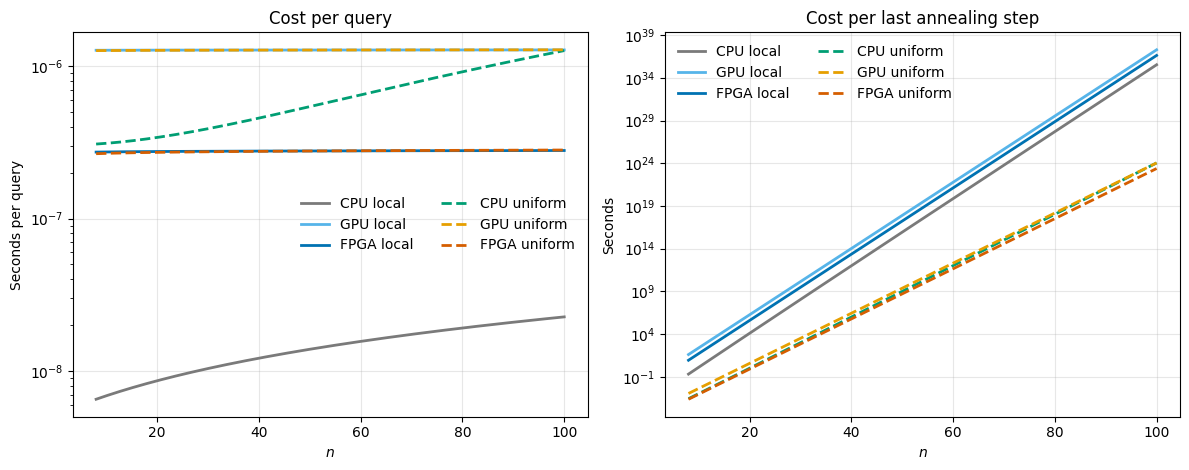

In [2]:
from monaqa2.data.single_step_classical5 import plot_time_to_solve_classically_comparison

fig, axes = plot_time_to_solve_classically_comparison(
    beta=4.0,
    a=np.inf,
    q0_mode="uniform",
    epsilon=1e-2,
)